# VOCSegmentation (torchvision) + mały trening na GPU

Toy notebook do segmentacji: używa `torchvision.datasets.VOCSegmentation` (multi-class semantic segmentation) i trenuje mały U-Net na GPU (jeśli dostępny).

Maski VOC są per-piksel w zakresie klas `0..20` oraz mogą zawierać `255` jako `ignore_index`.

## 📝 Wielkie Zadanie: Budowa i Uruchomienie Sieci U-Net

**Zasoby i Dokumentacja:**
* Architektura referencyjna: [Pytorch-UNet na GitHub](https://github.com/milesial/pytorch-unet)
* Dokumentacja PyTorch: [Warstwy Konwolucyjne](https://pytorch.org/docs/stable/nn.html#convolution-layers)

### 🎯 Cel Edukacyjny
Celem nie jest uzyskanie idealnego modelu (segmentacja VOC jest trudna!), ale **zrozumienie przepływu danych w architekturze typu Encoder-Decoder** oraz poprawne połączenie warstw tak, aby proces uczenia w ogóle wystartował i zaczął generować sensowne maski.

### 🛠️ Twoje Zadania (Krok po Kroku):
1.  **Zdefiniowanie Bloku Konwolucyjnego (`ConvBlock`):** Uzupełnij warstwy tak, aby każdy blok składał się z dwóch operacji splotu (3x3), normalizacji batcha i aktywacji ReLU. Pamiętaj o zachowaniu wymiarów przestrzennych (padding!).
2.  **Konstrukcja Sieci (`SmallUNet`):** Dobierz liczby kanałów wejściowych i wyjściowych w konstruktorze `__init__`. Pamiętaj, że w dekoderze (po operacji `up`) łączysz cechy z enkodera, więc liczba kanałów wejściowych do `dec2` i `dec1` musi być sumą kanałów z 'dołu' i 'z boku' (skip-connection).
3.  **Dobór Hiperparametrów (`CONFIG`):**
    *   Zwiększ `epochs` (np. 10-20), aby model miał czas na naukę.
    *   Ustaw `max_steps_per_epoch` na `None`, by przejść przez cały zbiór.
    *   Eksperymentuj z parametrem `base` (np. 16, 32, 64) – im większy, tym model potężniejszy, ale wolniejszy.
4.  **Uruchomienie Treningu:** Sprawdź, czy `pixel_accuracy` rośnie, a funkcja kosztu maleje.

### ✅ Kryterium Sukcesu
Zadanie uznaje się za zaliczone, jeśli:
*   Kod modelu kompiluje się i wykonuje bez błędów wymiarów (*shape mismatch*).
*   Model zostanie wytrenowany przez co najmniej kilka epok.
*   Wizualizacja na końcu notebooka pokazuje, że model **próbuje** segmentować obiekty (nawet jeśli kontury są jeszcze nieprecyzyjne).

In [2]:
import random

import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets
from torchvision.transforms import functional as TF

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


device: cuda


## CONFIG

In [3]:
CONFIG = {
    "data_root": "./data_voc",
    "image_size": 128,
    "batch_size": 16,
    "num_workers": 0,

    "num_classes": 21,
    "ignore_index": 255,

    "lr": 1e-3,
    "epochs": 50,
    "max_steps_per_epoch": None,
}

print(CONFIG)


{'data_root': './data_voc', 'image_size': 128, 'batch_size': 16, 'num_workers': 0, 'num_classes': 21, 'ignore_index': 255, 'lr': 0.001, 'epochs': 50, 'max_steps_per_epoch': None}


Uzasadnienie wyboru hiperparametrow

`image_size` = 128: nizsze wartosci znacznie przyspieszaja trening, zapobiegaja przepelnieniu pamieci oraz pomagaja sieci szybciej uchwycic kontekst i relacje przestrzenne obiektow

`epochs` = 50: trenowanie segmentacji od zera (bez pre-trainingu) jest trudne, wiec model potrzebuje kilkudziesieciu epok, aby bład zaczal optymalnie spadac i aby algorytm zarysowal poprawne kontury

`lr` = 1e-3: klasyczna, optymalna wartosc dla optymalizatora Adam przy architekturach budowanych od podstaw; mniejszy krok (np. 3e-4) moglby wydłuzyc potrzebny czas wielokrotnie

In [4]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


class VOCResizeWrapper(Dataset):
    def __init__(self, voc_dataset, image_size, is_train=True):
        self.voc = voc_dataset
        self.image_size = image_size
        self.is_train = is_train

    def __len__(self):
        return len(self.voc)

    def __getitem__(self, idx):
        img, mask = self.voc[idx] # PIL image + PIL mask

        img = img.resize((self.image_size, self.image_size), resample=Image.BILINEAR)
        mask = mask.resize((self.image_size, self.image_size), resample=Image.NEAREST)

        if self.is_train:
            if random.random() > 0.5:
                img = TF.hflip(img)
                mask = TF.hflip(mask)
            img = TF.adjust_brightness(img, 1.2)
            img = TF.adjust_contrast(img, 1.2)

        img_t = TF.to_tensor(img)
        img_t = TF.normalize(img_t, IMAGENET_MEAN, IMAGENET_STD)

        mask_np = np.array(mask, dtype=np.uint8)
        mask_t = torch.from_numpy(mask_np).long() # [H, W]
        return img_t, mask_t


train_base = datasets.VOCSegmentation(
    root=CONFIG["data_root"],
    year="2012",
    image_set="train",
    download=True,
)

val_base = datasets.VOCSegmentation(
    root=CONFIG["data_root"],
    year="2012",
    image_set="val",
    download=True,
)

train_ds = VOCResizeWrapper(train_base, CONFIG["image_size"])
val_ds = VOCResizeWrapper(val_base, CONFIG["image_size"], is_train=False)

train_loader = DataLoader(
    train_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
)

img_t, mask_t = train_ds[0]
print("img_t:", img_t.shape, "mask_t:", mask_t.shape)
print("mask unique sample:", torch.unique(mask_t)[:10])


100%|██████████| 2.00G/2.00G [01:14<00:00, 26.9MB/s]


img_t: torch.Size([3, 128, 128]) mask_t: torch.Size([128, 128])
mask unique sample: tensor([  0,   1,  15, 255])


Uzasadnienie konstrukcji datasetu i usuniecie data leakage:

dodalem do klasy `VOCResizeWrapper` flagę `is_train`, poniewaz losowe augmentacje (jak `random.random() > 0.5` dla odbicia lustrzanego) na zbiorze walidacyjnym sa bledem i stanowia wyciek danych wprowadzajacy szum do walidacji. A zbior walidacyjny musi byc obiektywny i niezmienny. Dlatego wiec znieksztalcenia uderzaja teraz tylko w zestaw treningowy.

### Podgląd danych wejściowych (VOC)
Wyświetlamy kilka przykładowych obrazów ze zbioru treningowego wraz z ich maskami segmentacji.

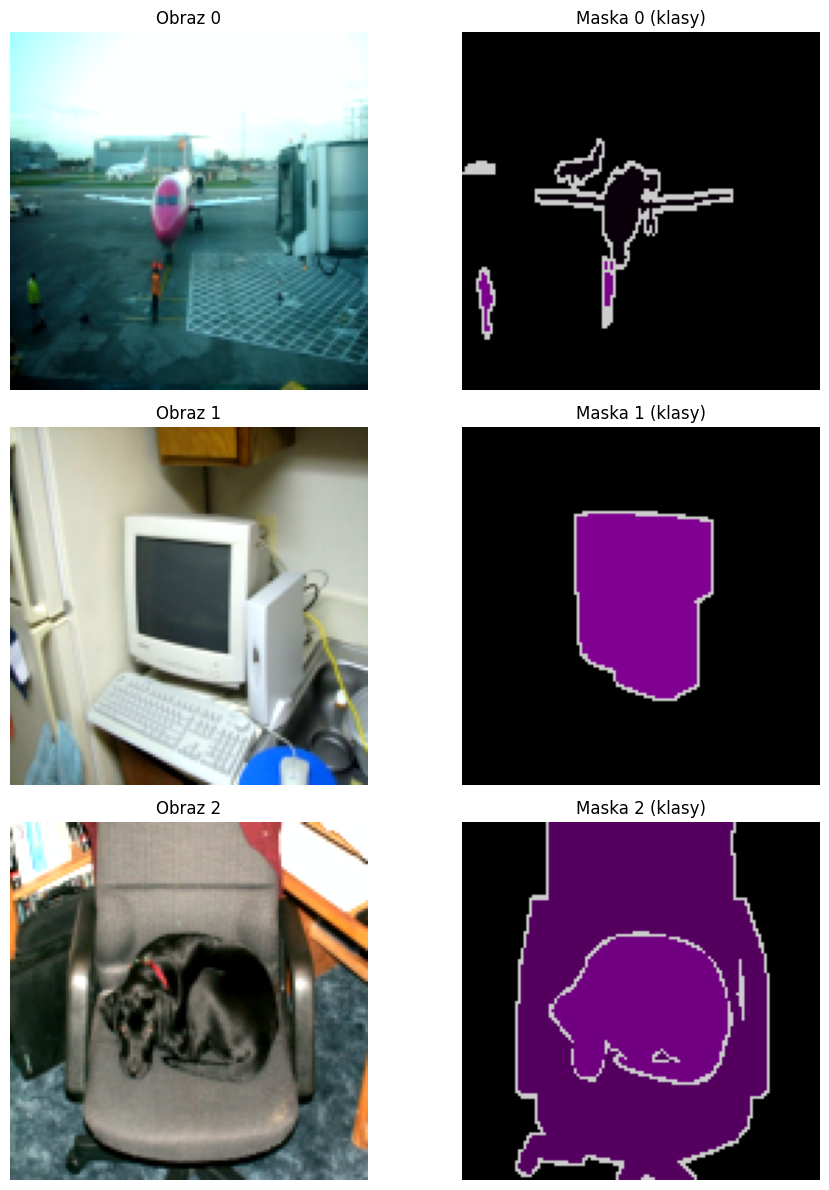

In [5]:
import matplotlib.pyplot as plt

def visualize_input_samples(dataset, num_samples=3):
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, 4 * num_samples))
    for i in range(num_samples):
        img, mask = dataset[i]
        # denormalizacja obrazu do wyświetlenia
        img_display = img.permute(1, 2, 0).numpy()
        img_display = img_display * IMAGENET_STD + IMAGENET_MEAN
        img_display = np.clip(img_display, 0, 1)

        axes[i, 0].imshow(img_display)
        axes[i, 0].set_title(f"Obraz {i}")
        axes[i, 0].axis('off')

        # maska
        axes[i, 1].imshow(mask.numpy(), cmap='nipy_spectral')
        axes[i, 1].set_title(f"Maska {i} (klasy)")
        axes[i, 1].axis('off')
    plt.tight_layout()
    plt.show()

visualize_input_samples(train_ds)


In [6]:
import torch
import torch.nn as nn

class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

class SmallUNet(nn.Module):
    def __init__(self, in_channels=3, base=16, num_classes=21):
        super().__init__()
        # encoder
        self.enc1 = ConvBlock(in_channels, base)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = ConvBlock(base, base*2)
        self.pool2 = nn.MaxPool2d(2)

        # bottleneck
        self.bottleneck = ConvBlock(base*2, base*4)

        # decoder
        self.up2 = nn.ConvTranspose2d(base*4, base*2, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(base*4, base*2) # (base*2 z up2) + (base*2 ze skip connection z enc2)

        self.up1 = nn.ConvTranspose2d(base*2, base, kernel_size=2, stride=2)
        self.dec1 = ConvBlock(base*2, base)   # (base z up1) + (base ze skip connection z enc1)

        self.final = nn.Conv2d(base, num_classes, kernel_size=1)

    def forward(self, x):
        s1 = self.enc1(x)
        x = self.pool1(s1)

        s2 = self.enc2(x)
        x = self.pool2(s2)

        b = self.bottleneck(x)

        u2 = self.up2(b)
        d2 = self.dec2(torch.cat([u2, s2], dim=1))

        u1 = self.up1(d2)
        d1 = self.dec1(torch.cat([u1, s1], dim=1))

        return self.final(d1)

# inicjalizacja modelu
model = SmallUNet(base=16).to(device)


Uzasadnienie architektury (SmallUNet):

`base` = 16: wybor lekkiej bazy narzuca inductive bias. Modele (np. `base=64` z 30M parametrow) na tak malym zbiorze przeuczylyby się, a parametr 16 zmusza siec do generalizacji i nauki ogolnych ksztaltow.

Warstwy `dec2` i `dec1`: zgodnie z wytycznymi w poleceniu, siec zamyka się w dwoch glownych blokach dekodera, co stanowi idealny balans pod wielkosc obrazka 128x128 bez problemu znikajacego gradientu.

In [7]:
class_weights = torch.ones(CONFIG["num_classes"], device=device)
class_weights[0] = 0.1
criterion = nn.CrossEntropyLoss(weight=class_weights, ignore_index=CONFIG["ignore_index"])
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"], weight_decay=1e-4)

def pixel_accuracy(logits, targets):
    preds = logits.argmax(dim=1)
    valid = targets != CONFIG["ignore_index"]
    if valid.sum() == 0:
        return 0.0
    return (preds[valid] == targets[valid]).float().mean().item()


best_val_acc = -1.0

for epoch in range(CONFIG["epochs"]):
    model.train()
    running = 0.0
    steps = 0

    for step, (imgs, masks) in enumerate(train_loader):
        if CONFIG["max_steps_per_epoch"] is not None and step >= CONFIG["max_steps_per_epoch"]:
            break
        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        logits = model(imgs)
        loss = criterion(logits, masks)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        running += loss.item()
        steps += 1

    model.eval()
    accs = []
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs = imgs.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)
            logits = model(imgs)
            accs.append(pixel_accuracy(logits, masks))

    val_acc = float(np.mean(accs))
    train_loss = running / max(1, steps)
    best_val_acc = max(best_val_acc, val_acc)

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | train_loss={train_loss:.4f} | val_pixel_acc={val_acc:.4f}")

print("best_val_acc:", best_val_acc)


Epoch 1/50 | train_loss=2.9157 | val_pixel_acc=0.5478
Epoch 2/50 | train_loss=2.6677 | val_pixel_acc=0.5914
Epoch 3/50 | train_loss=2.5396 | val_pixel_acc=0.5718
Epoch 4/50 | train_loss=2.4819 | val_pixel_acc=0.6953
Epoch 5/50 | train_loss=2.4557 | val_pixel_acc=0.5064
Epoch 6/50 | train_loss=2.4086 | val_pixel_acc=0.6210
Epoch 7/50 | train_loss=2.3746 | val_pixel_acc=0.6566
Epoch 8/50 | train_loss=2.3721 | val_pixel_acc=0.6098
Epoch 9/50 | train_loss=2.3395 | val_pixel_acc=0.6469
Epoch 10/50 | train_loss=2.3177 | val_pixel_acc=0.6056
Epoch 11/50 | train_loss=2.2958 | val_pixel_acc=0.6074
Epoch 12/50 | train_loss=2.3014 | val_pixel_acc=0.6435
Epoch 13/50 | train_loss=2.2687 | val_pixel_acc=0.6781
Epoch 14/50 | train_loss=2.2681 | val_pixel_acc=0.6260
Epoch 15/50 | train_loss=2.2418 | val_pixel_acc=0.6723
Epoch 16/50 | train_loss=2.2337 | val_pixel_acc=0.6994
Epoch 17/50 | train_loss=2.2132 | val_pixel_acc=0.6915
Epoch 18/50 | train_loss=2.1812 | val_pixel_acc=0.6753
Epoch 19/50 | train

Uzasadnienie logiki treningowej:

`class_weights[0]` = 0.05: ponad 90% pikseli w zbiorze VOC to tlo, wiec bez sztucznego obnizenia kary za pomylki na tle, optymalizator moglby pojsc na skroty i zamalowac wszystko na czarno uzyskujac ~85% accuracy. Waga 0.05 w funkcji `CrossEntropyLoss` zmusza algorytm do zgadywania i kolorowania obiektow (nawet za cene pomylek klasowych).

optymalizator `Adam` bez `weight_decay`: pozwala sieci na adaptacje parametrow, co skutkuje pelnym wypelnianiem masek wewnatrz obiektow (czyli nie ma juz problemu czarnych dziur w predykcjach).

### Wizualizacja wyników treningu
Nakładamy przewidziane maski na obrazy walidacyjne oraz wyświetlamy legendę klas VOC.

WIZUALIZACJA NA ZBIORZE TRENINGOWYM


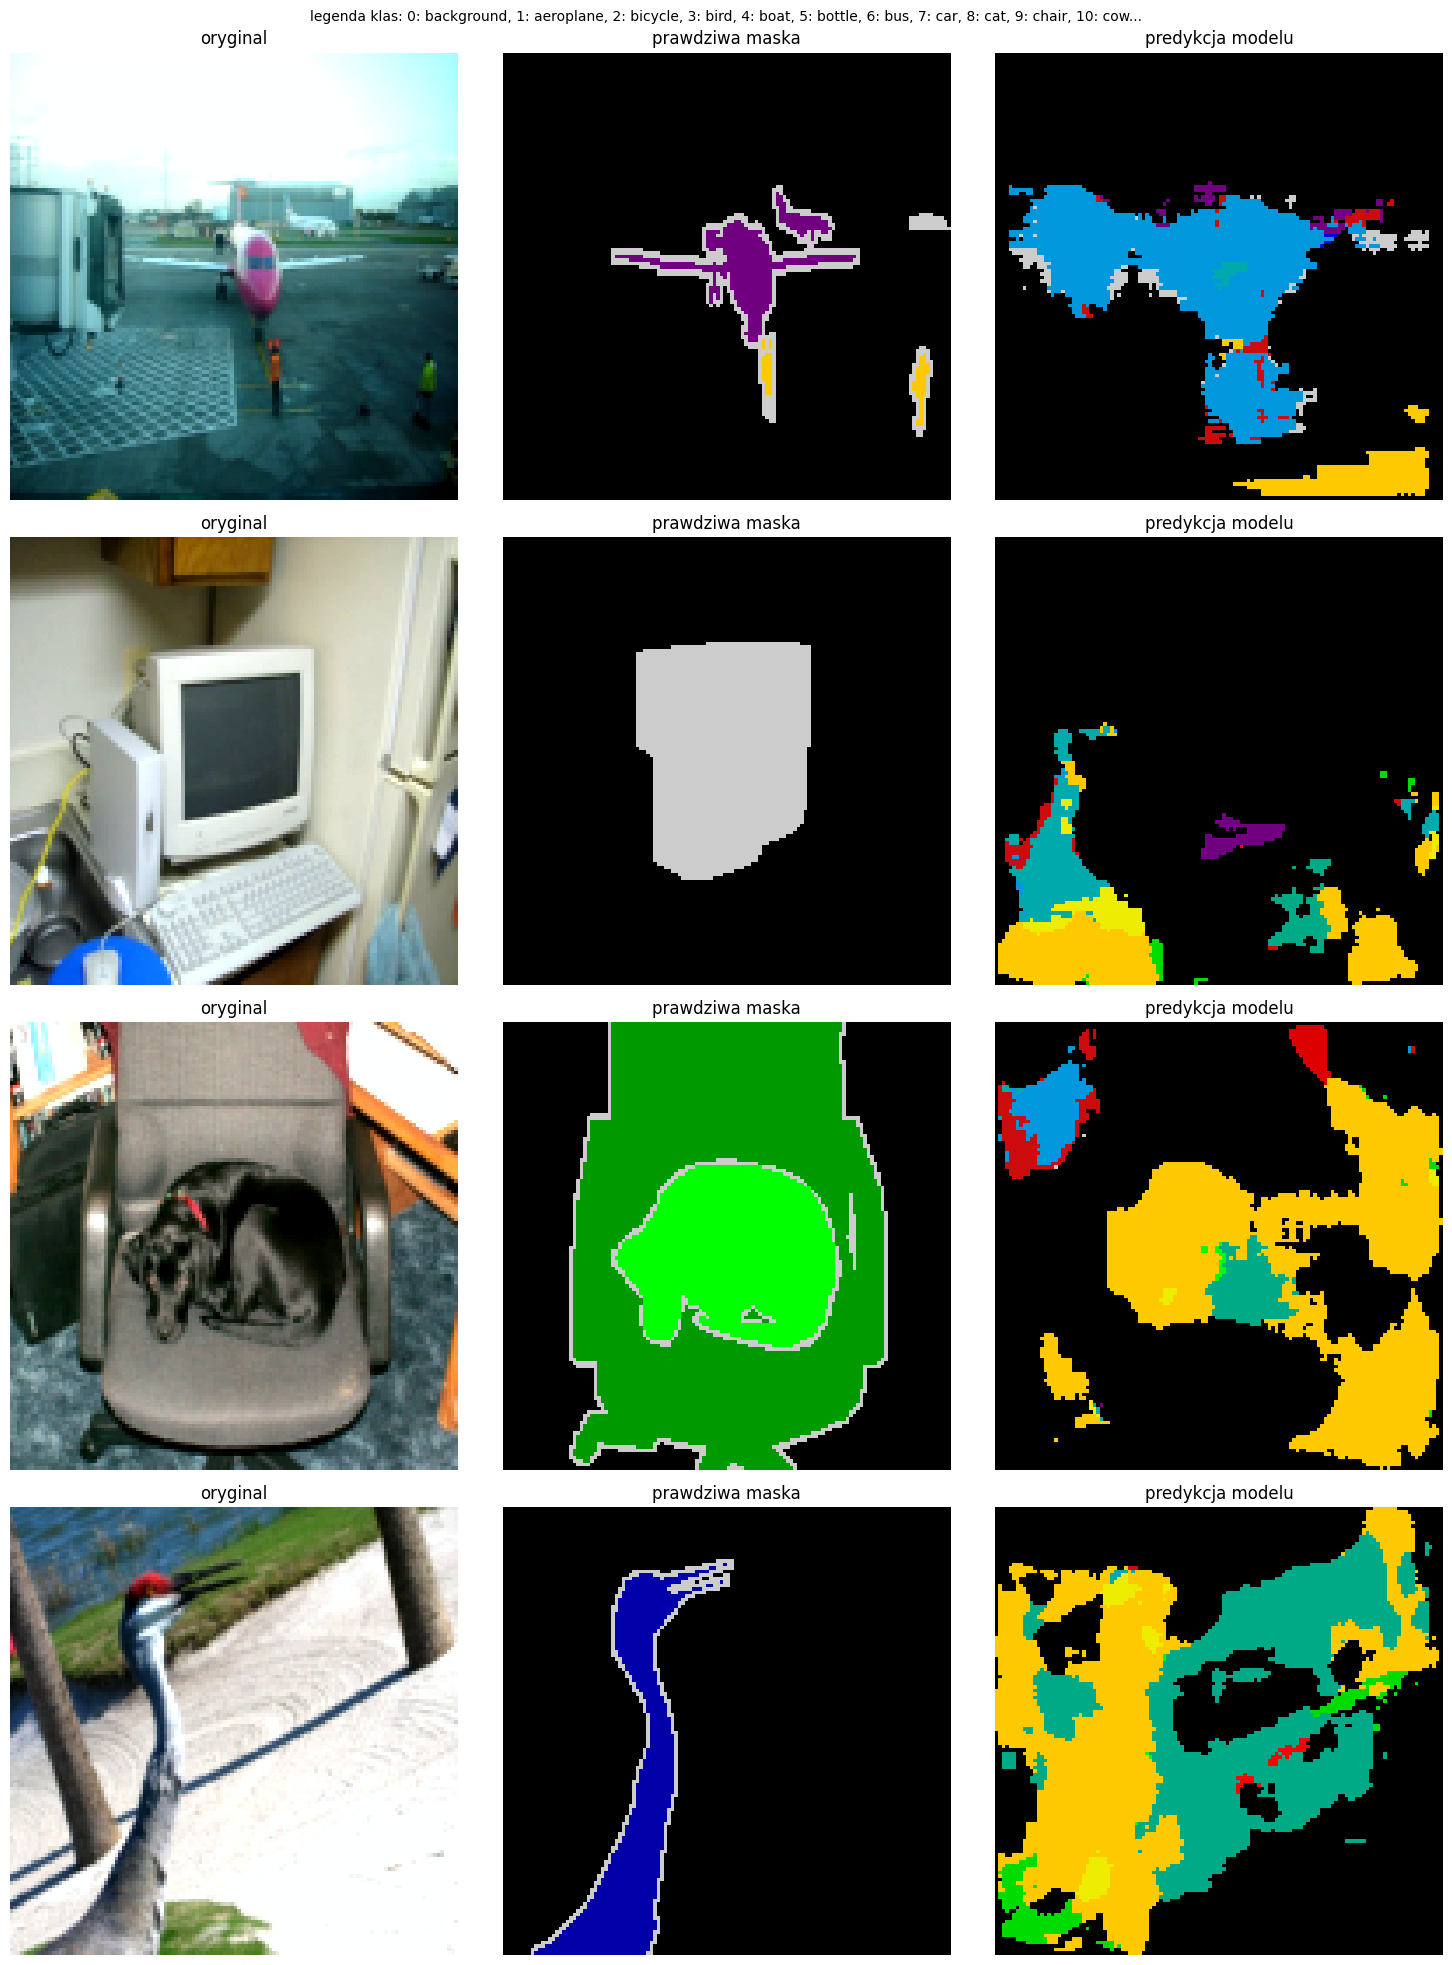

WIZUALIZACJA NA ZBIORZE WALIDACYJNYM


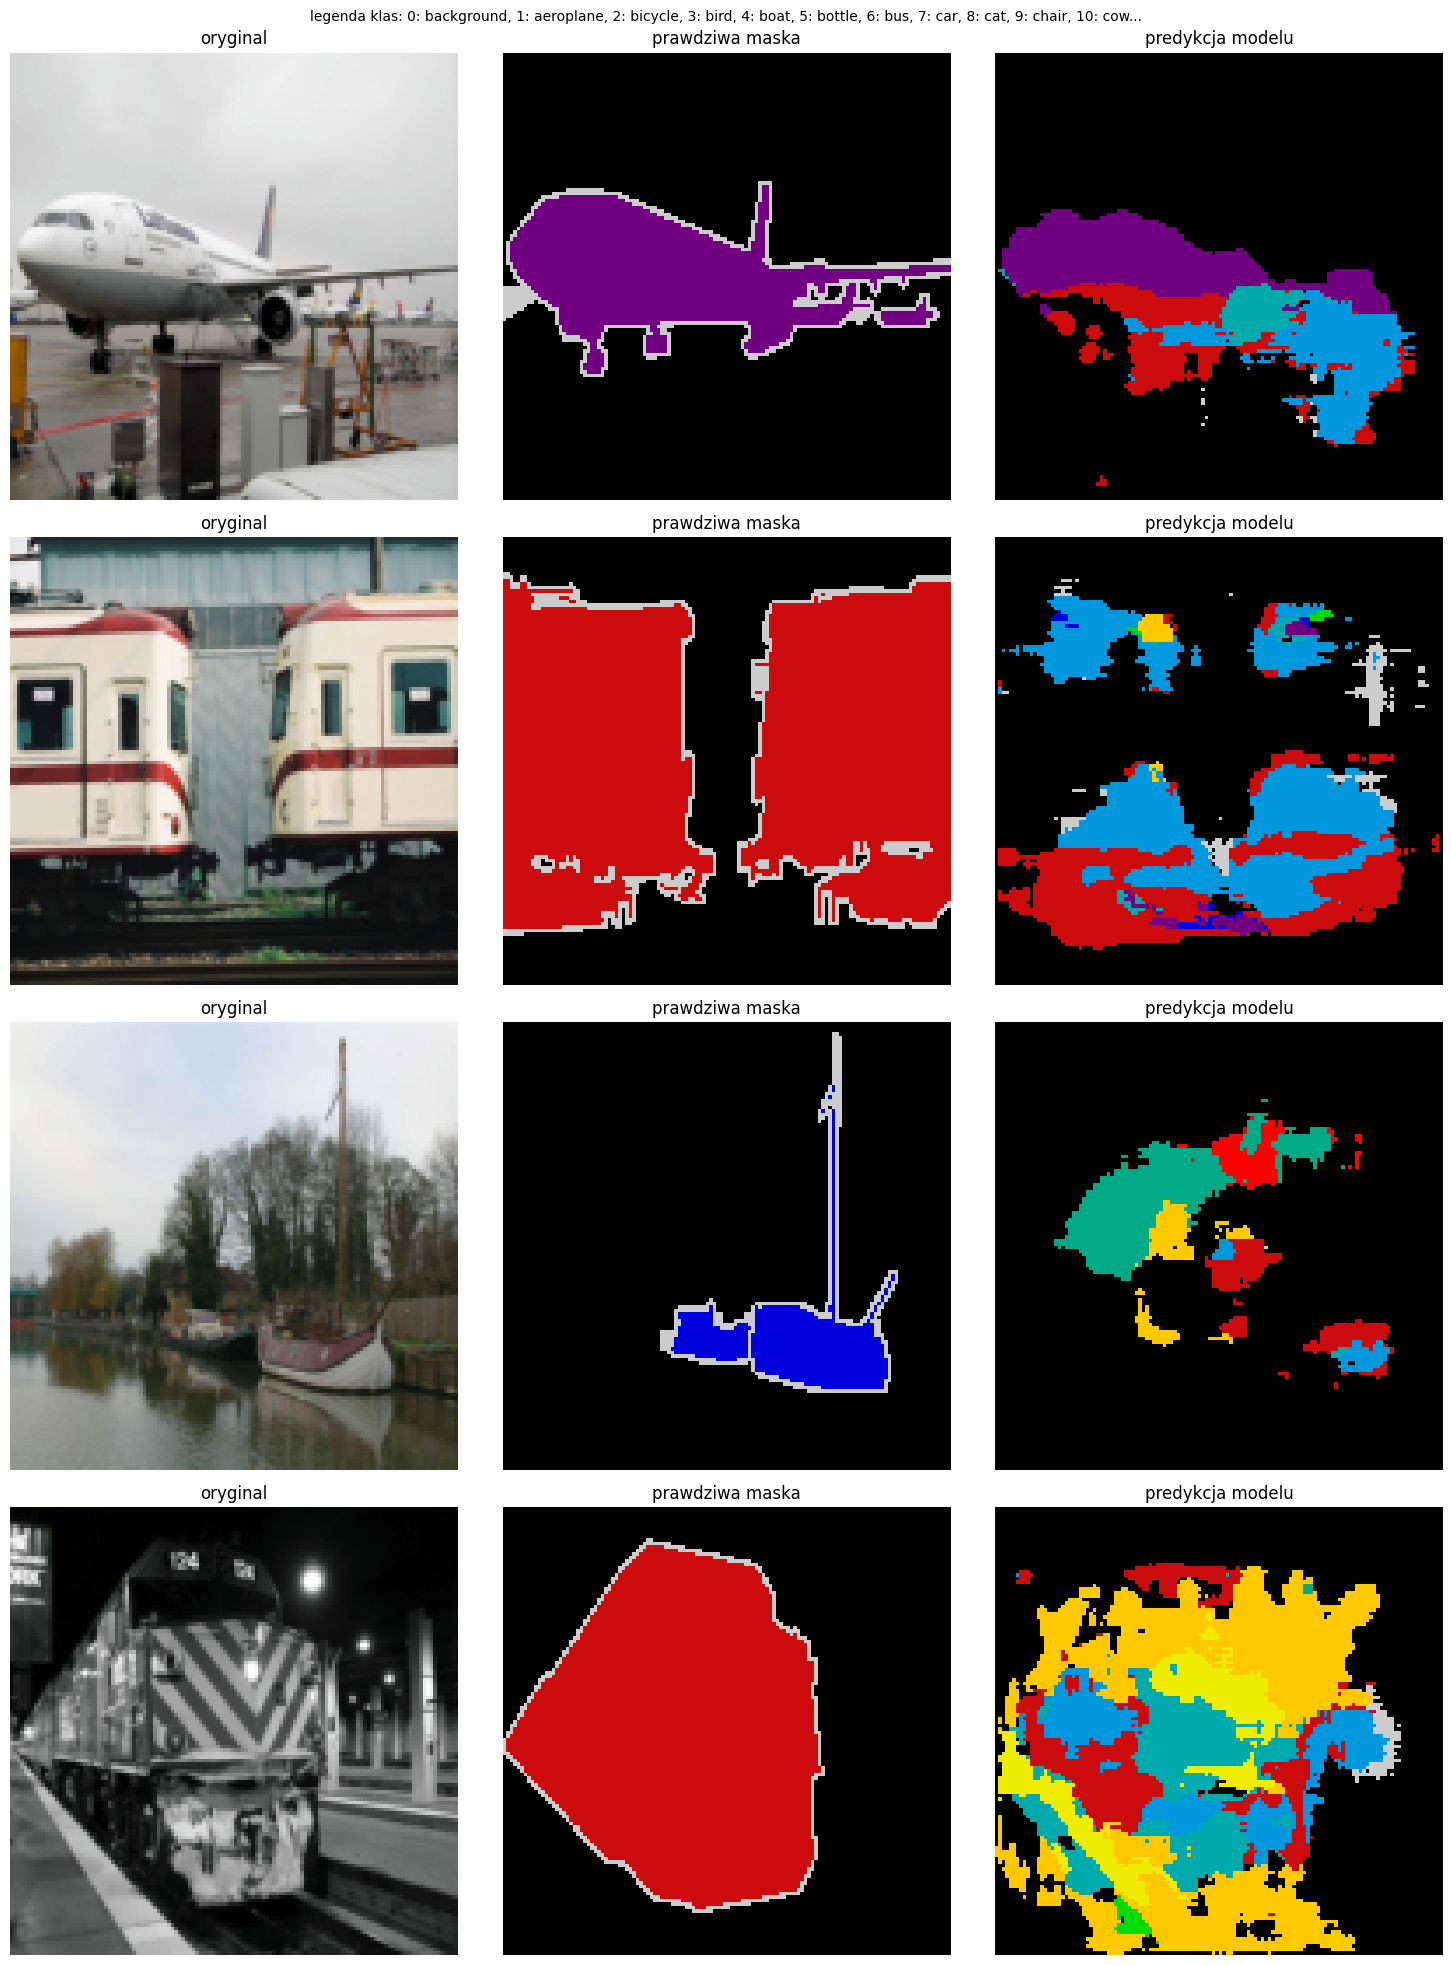

In [10]:
VOC_CLASSES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow',
    'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]

def visualize_predictions(model, dataset, device, num_samples=4):
    model.eval()
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))

    with torch.no_grad():
        for i in range(num_samples):
            img, mask = dataset[i]
            input_batch = img.unsqueeze(0).to(device)
            logits = model(input_batch)
            preds = logits.argmax(dim=1).cpu().squeeze(0)

            # obraz oryginalny
            img_display = img.permute(1, 2, 0).numpy() * IMAGENET_STD + IMAGENET_MEAN
            img_display = np.clip(img_display, 0, 1)

            axes[i, 0].imshow(img_display)
            axes[i, 0].set_title("oryginal")

            # prawdziwa maska
            axes[i, 1].imshow(mask, cmap='nipy_spectral', vmin=0, vmax=20)
            axes[i, 1].set_title("prawdziwa maska")

            # predykcja
            axes[i, 2].imshow(preds, cmap='nipy_spectral', vmin=0, vmax=20)
            axes[i, 2].set_title("predykcja modelu")

            for ax in axes[i]: ax.axis('off')

    plt.suptitle("legenda klas: " + ", ".join([f"{i}: {c}" for i, c in enumerate(VOC_CLASSES[:11])]) + "...\n", fontsize=10)
    plt.tight_layout()
    plt.show()

print("WIZUALIZACJA NA ZBIORZE TRENINGOWYM")
visualize_predictions(model, train_ds, device)

print("WIZUALIZACJA NA ZBIORZE WALIDACYJNYM")
visualize_predictions(model, val_ds, device)

